In [1]:
import pandas as pd

# Load the dataset
data = pd.read_csv('ce889_dataCollection.csv', header=None)

In [2]:
data

,0,1,2,3
0,-239.026763,479.900000,0.000000,0.000000
1,-239.026763,479.900000,-0.100000,0.040000
2,-239.066763,480.000000,-0.200000,0.000000
3,-239.066763,480.200000,-0.300000,0.040000
4,-239.106763,480.500000,-0.400000,0.000000
...,...,...,...,...
8711,28.191443,93.473316,5.733686,0.588519
8712,27.602924,87.739629,5.833686,0.548519
8713,27.054404,81.905943,5.933686,0.508519
8714,26.545885,75.972257,6.033686,0.468519


In [3]:
data.shape

(8716, 4)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8716 entries, 0 to 8715
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       8716 non-null   float64
 1   1       8716 non-null   float64
 2   2       8716 non-null   float64
 3   3       8716 non-null   float64
dtypes: float64(4)
memory usage: 272.5 KB


In [5]:
data.isnull().sum()

0    0
1    0
2    0
3    0
dtype: int64

In [6]:
data.describe()

,0,1,2,3
count,8716.000000,8716.000000,8716.000000,8716.000000
mean,-32.699501,376.318184,0.808177,0.165110
std,222.484714,136.614232,2.147111,1.423761
min,-583.340674,65.717500,-3.895535,-4.840110
25%,-125.002655,272.660508,-0.717279,-0.333386
50%,-17.431620,368.752081,0.578086,0.002914
75%,97.302134,486.625393,2.033250,0.604684
max,495.527575,664.945445,8.000000,4.682816


In [7]:
# Splitting the data into inputs (X, Y) and outputs (Lander thruster, Lander turning)
inputs = data.iloc[:, :2].values  # X and Y positions
outputs = data.iloc[:, 2:].values  # Lander thruster and turning

In [8]:
inputs

array([[-239.02676333,  479.9       ],
       [-239.02676333,  479.9       ],
       [-239.06676333,  480.        ],
       ...,
       [  27.05440404,   81.90594305],
       [  26.54588457,   75.97225668],
       [  26.0773651 ,   69.93857032]])

In [9]:
outputs

array([[ 0.        ,  0.        ],
       [-0.1       ,  0.04      ],
       [-0.2       ,  0.        ],
       ...,
       [ 5.93368637,  0.50851947],
       [ 6.03368637,  0.46851947],
       [ 6.13368637,  0.42851947]])

In [10]:
import numpy as np

In [11]:
# Normalize the inputs 
inputs = (inputs - np.mean(inputs, axis=0)) / np.std(inputs, axis=0)

In [12]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
split = int(0.8 * len(data))  # 80% for training, 20% for validation
train_inputs, val_inputs = inputs[:split], inputs[split:]
train_outputs, val_outputs = outputs[:split], outputs[split:]

In [13]:
# Define neural network architecture
input_size = inputs.shape[1]  # Number of input features (X, Y)
output_size = outputs.shape[1]  # Number of output features (thruster, turning)

In [14]:
input_size

2

In [15]:
output_size

2

In [16]:
hidden_layer_size = 16  # Number of neurons in the hidden layer

# Initialize weights and biases
weights_input_hidden = np.random.rand(input_size, hidden_layer_size)
biases_input_hidden = np.zeros((1, hidden_layer_size))

weights_hidden_output = np.random.rand(hidden_layer_size, output_size)
biases_hidden_output = np.zeros((1, output_size))

In [17]:
# Define activation function (sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [18]:
# Define derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

In [19]:
# Define learning rate and number of epochs
learning_rate = 0.1
epochs = 100

In [20]:
print("Train Inputs Shape:", train_inputs.shape)
print("Train Outputs Shape:", train_outputs.shape)
print("Validation Inputs Shape:", val_inputs.shape)
print("Validation Outputs Shape:", val_outputs.shape)


Train Inputs Shape: (6972, 2)
Train Outputs Shape: (6972, 2)
Validation Inputs Shape: (1744, 2)
Validation Outputs Shape: (1744, 2)


In [21]:
# Lists to store RMSE values
rmse_train = []
rmse_val = []

# Training the neural network
for epoch in range(epochs):
    # Forward pass for training data
    hidden_layer_input = np.dot(train_inputs, weights_input_hidden) + biases_input_hidden
    hidden_layer_output = sigmoid(hidden_layer_input)
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + biases_hidden_output
    predicted_output = sigmoid(output_layer_input)
    train_rmse = np.sqrt(np.mean((train_outputs - predicted_output) ** 2))
    rmse_train.append(train_rmse)

    # Backpropagation and update weights and biases
    output_error = train_outputs - predicted_output
    output_delta = output_error * sigmoid_derivative(predicted_output)
    
    hidden_error = output_delta.dot(weights_hidden_output.T)
    hidden_delta = hidden_error * sigmoid_derivative(hidden_layer_output)
    
    weights_hidden_output += hidden_layer_output.T.dot(output_delta) * learning_rate
    biases_hidden_output += np.sum(output_delta, axis=0, keepdims=True) * learning_rate
    weights_input_hidden += train_inputs.T.dot(hidden_delta) * learning_rate
    biases_input_hidden += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate

    # Forward pass for validation data
    val_hidden_layer_input = np.dot(val_inputs, weights_input_hidden) + biases_input_hidden
    val_hidden_layer_output = sigmoid(val_hidden_layer_input)
    val_output_layer_input = np.dot(val_hidden_layer_output, weights_hidden_output) + biases_hidden_output
    predicted_val_output = sigmoid(val_output_layer_input)
    val_rmse = np.sqrt(np.mean((val_outputs - predicted_val_output) ** 2))
    rmse_val.append(val_rmse)

In [22]:
weights_hidden_output

array([[ 1.15997541, -3.47659919],
       [-0.44807756, -5.2667985 ],
       [-0.95871007, -3.74716957],
       [ 1.57583936, -3.4705913 ],
       [10.42533382, -2.66743372],
       [20.02670357, -3.2901274 ],
       [10.86683618, -2.56140119],
       [ 0.52369323, -3.08570589],
       [10.43672733, -3.06490033],
       [10.39801924, -3.38948891],
       [13.06574933, -3.63485283],
       [ 1.16628216, -2.88627374],
       [ 2.19969873, -4.94359627],
       [ 4.93919442, -2.97930014],
       [ 8.74289463, -4.33987416],
       [ 8.97226217, -2.54684689]])

In [23]:
biases_hidden_output

array([[ -6.95932849, -12.01666604]])

In [24]:
weights_input_hidden

array([[  2.86101964,   0.75175966,   3.03122701,   5.86484515,
         11.6307238 ,  10.93246293,   9.90305646,   3.15881703,
         17.87608353,  18.736352  ,  12.58514402,   4.30868465,
          4.35385985,   6.95975993,   9.49115337,   7.27489907],
       [  1.6487785 ,   5.92348923,   1.1352328 ,   1.28697441,
        -13.853008  , -15.18029436, -12.84451291,   2.63802747,
        -10.14825971,  -8.20174953, -18.90251781,   0.8127366 ,
          1.41200209,  -7.10924881,  -9.73499126,  -7.86487451]])

In [25]:
biases_input_hidden

array([[-3.6115148 , -6.7092317 , -5.83679802, -7.59791932, 16.17175349,
        -4.84438681, 12.0143117 , -6.28572322, 15.18152968, 12.68403885,
        15.15459946, -3.83720346, -4.40355002, -0.75653012, 10.63888315,
         7.31746385]])

In [26]:
rmse_val

[2.162161156436681,
 2.001421832891691,
 1.968863245332541,
 1.9592520073360062,
 2.0629889016559924,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307,
 2.001444254570307

In [27]:
rmse_train

[1.8894979129302798,
 1.8388793215931087,
 1.7758074440786644,
 1.7249472191305322,
 1.7187609417246479,
 1.7893251549663491,
 1.7372025173765364,
 1.7338070627310824,
 1.7334320575550264,
 1.732881745444018,
 1.732485300429338,
 1.7323843807348227,
 1.7323118751547604,
 1.7322798150796272,
 1.732176423804696,
 1.7321358063761438,
 1.7320969760280833,
 1.7320581989143045,
 1.7320205094991559,
 1.731988559093984,
 1.731965827637702,
 1.7319562776343187,
 1.732003091450915,
 1.7325876446686592,
 1.7333338899330548,
 1.7330113682641153,
 1.7324168625123624,
 1.7320924524208912,
 1.732089438489251,
 1.7321446124411974,
 1.732295182763182,
 1.7321215832557066,
 1.7322248142769294,
 1.7321451487603232,
 1.732281894650393,
 1.732072703044402,
 1.7321046164542404,
 1.7321539445682086,
 1.732295573965957,
 1.7320228362521828,
 1.7320301170811632,
 1.7321125045801828,
 1.732228378946883,
 1.7320281509096596,
 1.7320697522588555,
 1.7321045549427811,
 1.7322125613729096,
 1.7320066349470093,
 1.7

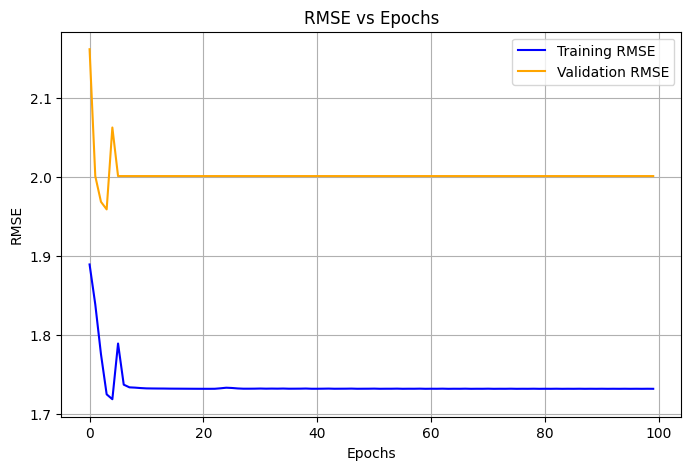

In [29]:
import matplotlib.pyplot as plt
# Plotting RMSE values over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), rmse_train, label='Training RMSE', color='blue')
plt.plot(range(epochs), rmse_val, label='Validation RMSE', color='orange')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('RMSE vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Calculate final RMSE for training and validation data
final_train_rmse = rmse_train[-1]
final_val_rmse = rmse_val[-1]

print("Final Training RMSE:", final_train_rmse)
print("Final Validation RMSE:", final_val_rmse)


Final Training RMSE: 1.7319524931943682
Final Validation RMSE: 2.001444254570307


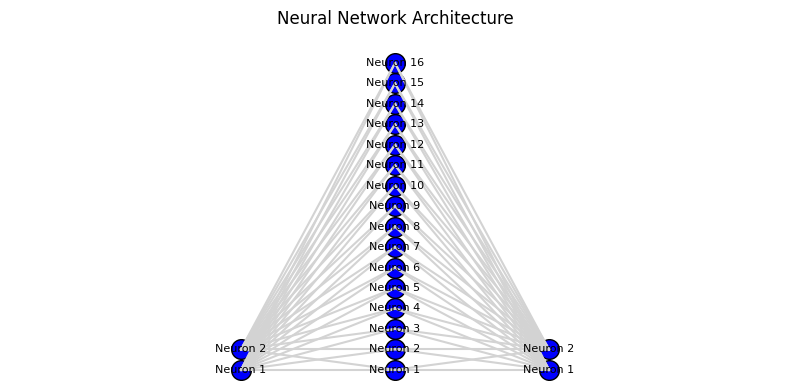

In [61]:
import matplotlib.pyplot as plt

# Define the number of neurons in each layer
input_neurons = 2
hidden_neurons = 16
output_neurons = 2

# Create a list to represent the number of neurons in each layer
neurons = [input_neurons, hidden_neurons, output_neurons]
layers = len(neurons)

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(8, 4))

# Define spacing between layers
layer_spacing = 2
neuron_spacing = 1

# Loop through layers to plot neurons
for i in range(layers):
    neuron_x_positions = neuron_spacing * (i - (layers - 1) / 2)
    for j in range(neurons[i]):
        ax.scatter(neuron_x_positions, j * neuron_spacing, color='blue', edgecolor='black', s=200)
        ax.text(neuron_x_positions, j * neuron_spacing, f'Neuron {j+1}', fontsize=8, ha='center', va='center')

# Loop through layers to plot connections
for i in range(layers - 1):
    start_neurons = neurons[i]
    end_neurons = neurons[i + 1]
    start_x = neuron_spacing * (i - (layers - 1) / 2)
    end_x = neuron_spacing * ((i + 1) - (layers - 1) / 2)
    for j in range(start_neurons):
        for k in range(end_neurons):
            ax.plot([start_x, end_x], [j * neuron_spacing, k * neuron_spacing], color='lightgrey')  # Adjusted color

# Set axis labels and limits
ax.set_xlabel('Layers')
ax.set_ylabel('Neurons')
ax.set_title('Neural Network Architecture')
ax.set_xticks(list(range(-2, 3, 1)))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-0.5, max(neurons) * neuron_spacing + 0.5)
ax.axis('off')

# Display the plot
plt.tight_layout()
plt.show()
